# Combined data analysis from all tables using Seaborn/Pyplot

In [23]:

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import seaborn as sns
import os
from dotenv import load_dotenv

In [24]:
# Load database credentials and create engine
load_dotenv()
db_name = os.getenv('DB_NAME')
db_user = os.getenv('DB_USER')
db_password = os.getenv('DB_PASSWORD')
db_host = os.getenv('DB_HOST')
db_port = os.getenv('DB_PORT')
engine = create_engine(f"postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}")

## Read data from database


In [25]:
# Read tables from the database
query_customers = 'SELECT * FROM customers'
df_customers = pd.read_sql_query(query_customers, engine)

query_products = 'SELECT * FROM products'
df_products = pd.read_sql_query(query_products, engine)

query_orders = 'SELECT * FROM orders'
df_orders = pd.read_sql_query(query_orders, engine)

print(f"Customers dataframe: {len(df_customers)} rows loaded from customers table")
print(f"Products dataframe: {len(df_products)} rows loaded from products table")
print(f"Orders dataframe: {len(df_orders)} rows loaded from orders table")

Customers dataframe: 1000 rows loaded from customers table
Products dataframe: 400 rows loaded from products table
Orders dataframe: 2000 rows loaded from orders table


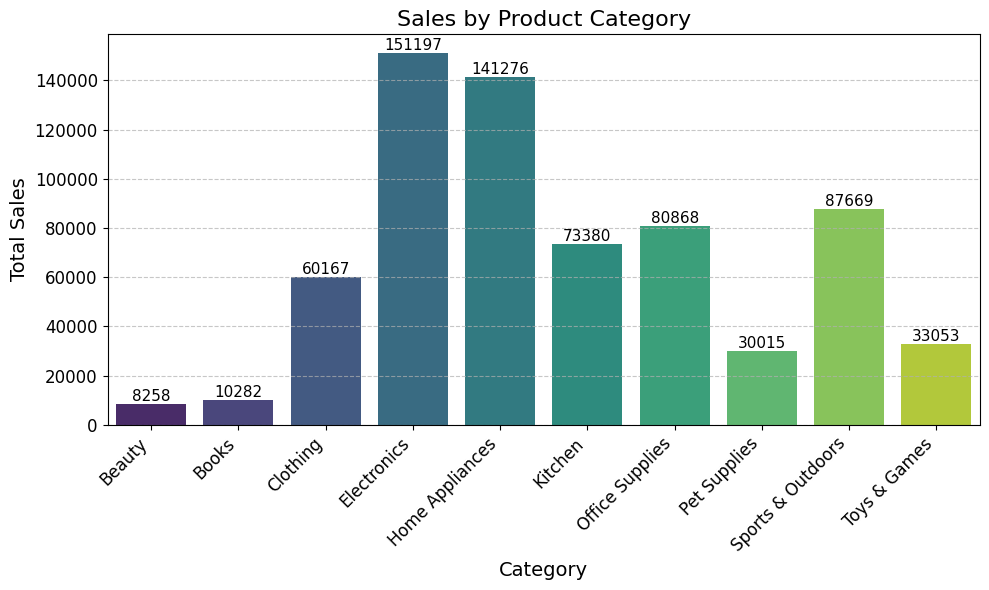

In [31]:
# 1. Sales by Product Category (bar chart)
merged_orders_products = df_orders.merge(df_products, left_on='product_id', right_on='product_id')
category_sales = merged_orders_products.groupby('category')['total_amount'].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=category_sales, x='category', y='total_amount', hue='category', palette='viridis', legend=False)
plt.title('Sales by Product Category', fontsize=16)
plt.xlabel('Category', fontsize=14)
plt.ylabel('Total Sales', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(category_sales['total_amount']):
    plt.text(i, v, f'{v:.0f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

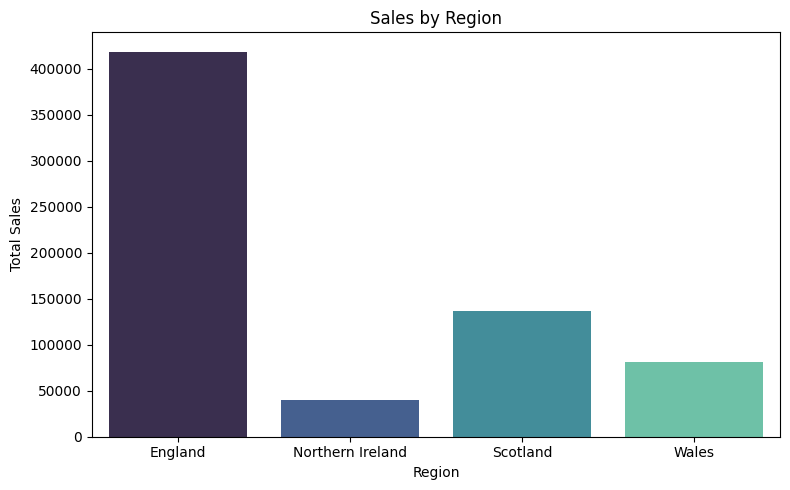

In [27]:
# 2. Sales by Region (bar chart)
merged_orders_customers = df_orders.merge(df_customers, left_on='customer_id', right_on='customer_id')
region_sales = merged_orders_customers.groupby('region')['total_amount'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=region_sales, x='region', y='total_amount', hue='region', palette='mako', legend=False)
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

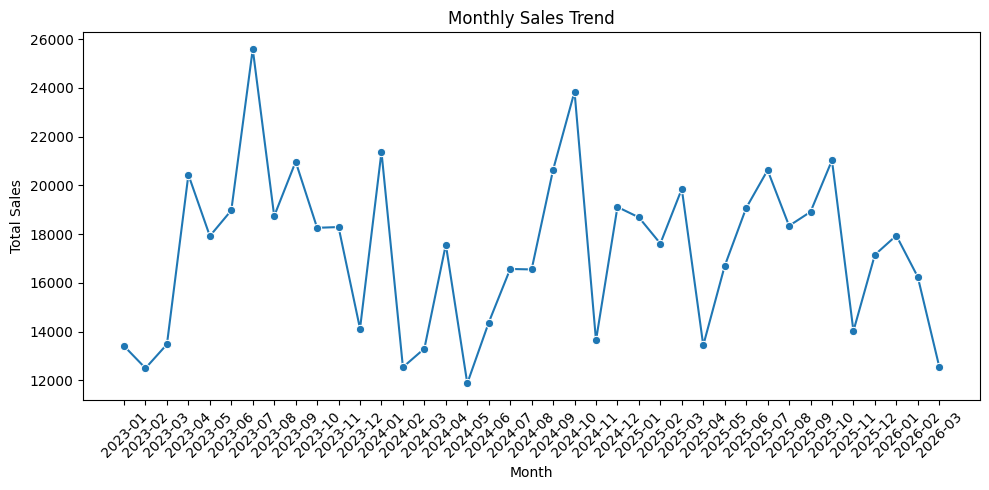

In [28]:
# 3. Monthly Sales Trend (line chart)
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_orders['month'] = df_orders['order_date'].dt.to_period('M')
monthly_sales = df_orders.groupby('month')['total_amount'].sum().reset_index()
monthly_sales['month'] = monthly_sales['month'].astype(str)
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_sales, x='month', y='total_amount', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

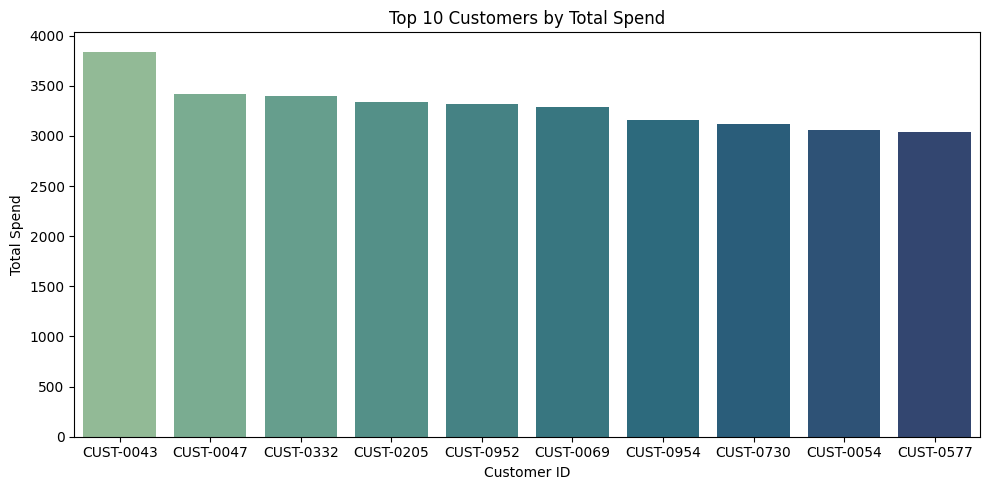

In [29]:
# 4. Top 10 Customers by Total Spend (bar chart)
top_customers = df_orders.groupby('customer_id')['total_amount'].sum().reset_index()
top_customers = top_customers.sort_values('total_amount', ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(data=top_customers, x='customer_id', y='total_amount', hue='customer_id', palette='crest', legend=False)
plt.title('Top 10 Customers by Total Spend')
plt.xlabel('Customer ID')
plt.ylabel('Total Spend')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

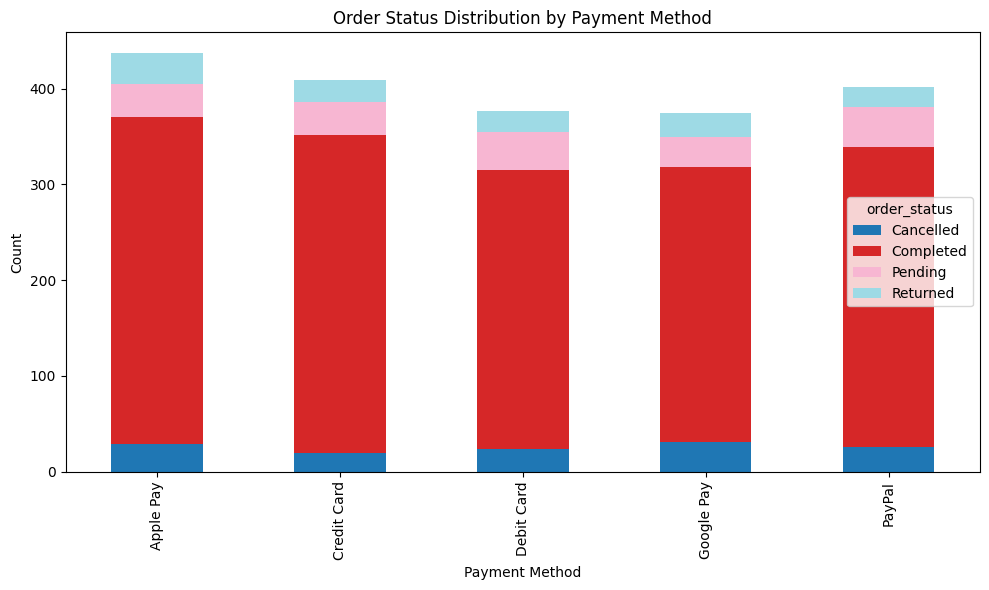

In [30]:
# 5. Order Status Distribution by Payment Method (stacked bar chart)
order_status_payment = df_orders.groupby(['payment_method', 'order_status']).size().reset_index(name='count')
plt.figure(figsize=(10, 6))
order_status_payment_pivot = order_status_payment.pivot(index='payment_method', columns='order_status', values='count').fillna(0)
order_status_payment_pivot.plot(kind='bar', stacked=True, colormap='tab20', figsize=(10, 6))
plt.title('Order Status Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.tight_layout()
plt.show()